In [5]:
import pandas as pd

df = pd.read_excel(r"C:\Users\daves\Desktop\EduFlow\eduflow\evaluator_service\evaluation\evaluation_results.xlsx")
print(df.shape)
df

(18, 11)


,Job ID,Architecture,Input Parameters,Duration,Number of Docs,Completion Time,Total Input Tokens,Total Output Tokens,Custom Matrics,Rubric - LLM,Pairwise - LLM
0,job-1774534470161,Eduflow,"{""job_id"": ""job-1774534470161"", ""callback_url""...",5,4,34,39405,9973,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
1,job-1774534999912,Baseline 1,"{""job_id"": ""job-1774534999912"", ""callback_url""...",5,4,26,29572,5201,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
2,job-1774544649734,Baseline 2,"{""job_id"": ""job-1774544649734"", ""callback_url""...",5,4,28,38306,7520,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
3,job-1774545286253,Eduflow,"{""job_id"": ""job-1774545286253"", ""callback_url""...",5,4,34,38608,9541,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
4,job-1774545754239,Baseline 1,"{""job_id"": ""job-1774545754239"", ""callback_url""...",5,4,26,27969,4850,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
5,job-1774547498894,Baseline 2,"{""job_id"": ""job-1774547498894"", ""callback_url""...",5,4,28,36614,7286,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
6,job-1774548177351,Eduflow,"{""job_id"": ""job-1774548177351"", ""callback_url""...",5,4,34,40186,9799,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none
7,job-1774548651030,Baseline 1,"{""job_id"": ""job-1774548651030"", ""callback_url""...",5,4,26,29479,4735,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
8,job-1774549026730,Baseline 2,"{""job_id"": ""job-1774549026730"", ""callback_url""...",5,4,28,38132,7318,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...","{""winner"": ""sequence_a"", ""win_counts"": {""seque..."
9,job-1774574045744,Eduflow,"{""job_id"": ""job-1774574045744"", ""callback_url""...",5,4,34,40286,10107,"{\n ""document_count"": 4,\n ""metrics"": {\n ...","{""architecture"": ""architecture A"", ""runs"": 3, ...",none


In [3]:
print(df.dtypes)

Job ID                 object
Architecture           object
Input Parameters       object
Duration                int64
Number of Docs          int64
Completion Time         int64
Total Input Tokens      int64
Total Output Tokens     int64
Custom Matrics         object
Rubric - LLM           object
Pairwise - LLM         object
dtype: object


In [6]:
df["Set"] = (df.index // 3) + 1
print(df[["Set", "Job ID", "Architecture"]])

    Set             Job ID Architecture
0     1  job-1774534470161      Eduflow
1     1  job-1774534999912   Baseline 1
2     1  job-1774544649734   Baseline 2
3     2  job-1774545286253      Eduflow
4     2  job-1774545754239   Baseline 1
5     2  job-1774547498894   Baseline 2
6     3  job-1774548177351      Eduflow
7     3  job-1774548651030   Baseline 1
8     3  job-1774549026730   Baseline 2
9     4  job-1774574045744      Eduflow
10    4  job-1774574325545   Baseline 1
11    4  job-1774574626655   Baseline 2
12    5  job-1774590551422      Eduflow
13    5  job-1774584736262   Baseline 1
14    5  job-1774584969330   Baseline 2
15    6  job-1774596210500      Eduflow
16    6  job-1774595522117   Baseline 1
17    6  job-1774596683553   Baseline 2


In [7]:
import json

def safe_parse(val):
    try:
        return json.loads(val)
    except:
        return None

df["rubric_parsed"]   = df["Rubric - LLM"].apply(safe_parse)
df["pairwise_parsed"] = df["Pairwise - LLM"].apply(safe_parse)
df["custom_parsed"]   = df["Custom Matrics"].apply(safe_parse)

# Quick check — show what we got
for col in ["rubric_parsed", "pairwise_parsed", "custom_parsed"]:
    none_count = df[col].isna().sum()
    print(f"{col}: {18 - none_count} parsed, {none_count} failed/null")

rubric_parsed: 18 parsed, 0 failed/null
pairwise_parsed: 12 parsed, 6 failed/null
custom_parsed: 18 parsed, 0 failed/null


In [8]:
# Extract rubric scores
df["rubric_overall_mean"]        = df["rubric_parsed"].apply(lambda x: x.get("overall_mean") if x else None)
df["rubric_coherence"]           = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("coherence") if x else None)
df["rubric_dependency_flow"]     = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("dependency_flow") if x else None)
df["rubric_content_progression"] = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("content_progression") if x else None)
df["rubric_non_redundancy"]      = df["rubric_parsed"].apply(lambda x: x["mean_scores"].get("non_redundancy") if x else None)

# Extract pairwise result
df["pairwise_winner"]     = df["pairwise_parsed"].apply(lambda x: x.get("winner") if x else None)
df["pairwise_consensus"]  = df["pairwise_parsed"].apply(lambda x: x.get("consensus") if x else None)

# Extract custom metrics — print keys first so we know what's inside
print(df["custom_parsed"][0].keys())

dict_keys(['document_count', 'metrics'])


In [9]:
print(df["custom_parsed"][0]["metrics"].keys())
print()
print(df["custom_parsed"][0]["metrics"])

dict_keys(['scaffolding_connectivity_score', 'concept_progression_velocity', 'long_range_scaffolding_depth'])

{'scaffolding_connectivity_score': {'overall': 0.5333, 'per_doc': [{'doc_id': 2, 'assumptions_count': 15, 'satisfied_count': 8, 'unsatisfied_concepts': ['M-item categories', 'Care Compare quality measures', 'Value-Based Purchasing outcomes', 'CMS Quarterly OASIS Q&As', 'Direct observation for assessment', 'Legal attestation in documentation', '50% rule for patient variability']}, {'doc_id': 3, 'assumptions_count': 15, 'satisfied_count': 9, 'unsatisfied_concepts': ['Risk stratification', 'CMS quality measures', 'Value-based purchasing initiatives', 'Skilled nursing interventions', 'Medical necessity documentation', 'Care plan goal setting']}, {'doc_id': 4, 'assumptions_count': 15, 'satisfied_count': 7, 'unsatisfied_concepts': ['CMS quality measures', 'value-based purchasing outcomes', 'Care Compare ratings', 'process measures for care coordination', 'utilization measures for he

In [10]:
# Extract custom metric scores
df["scs_overall"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["scaffolding_connectivity_score"].get("overall") if x else None
)
df["cpv"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["concept_progression_velocity"].get("cpv") if x else None
)
df["lrsd_avg_depth"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("average_depth") if x else None
)
df["lrsd_long_range_links"] = df["custom_parsed"].apply(
    lambda x: x["metrics"]["long_range_scaffolding_depth"].get("long_range_links") if x else None
)

# Check results
df[["Architecture", "Set", "scs_overall", "cpv", "lrsd_avg_depth", "lrsd_long_range_links"]]

,Architecture,Set,scs_overall,cpv,lrsd_avg_depth,lrsd_long_range_links
0,Eduflow,1,0.5333,0.9872,1.6667,4
1,Baseline 1,1,0.7778,0.9615,1.2500,1
2,Baseline 2,1,0.8947,0.9605,1.2667,4
3,Eduflow,2,0.5111,0.8846,1.6429,6
4,Baseline 1,2,0.4211,0.9315,1.9000,7
5,Baseline 2,2,0.3778,1.0000,2.3333,2
6,Eduflow,3,0.5581,1.0000,1.5000,7
7,Baseline 1,3,0.5750,0.9865,1.6667,4
8,Baseline 2,3,0.6000,0.9733,1.9091,7
9,Eduflow,4,0.5909,0.9481,1.6923,6


In [11]:
metrics = ["scs_overall", "cpv", "lrsd_avg_depth", "lrsd_long_range_links", 
           "rubric_overall_mean", "rubric_coherence", "rubric_dependency_flow", 
           "rubric_content_progression", "rubric_non_redundancy"]

summary = df.groupby("Architecture")[metrics].mean().round(4)
summary

,scs_overall,cpv,lrsd_avg_depth,lrsd_long_range_links,rubric_overall_mean,rubric_coherence,rubric_dependency_flow,rubric_content_progression,rubric_non_redundancy
Architecture,,,,,,,,,
Baseline 1,0.5702,0.9562,1.7741,4.5000,3.9717,4.0,4.0,4.8883,3.0000
Baseline 2,0.6511,0.9560,1.7725,5.1667,3.8617,4.0,4.0,4.4450,3.0000
Eduflow,0.5767,0.9464,1.6763,6.1667,4.8050,5.0,5.0,5.0000,4.2217


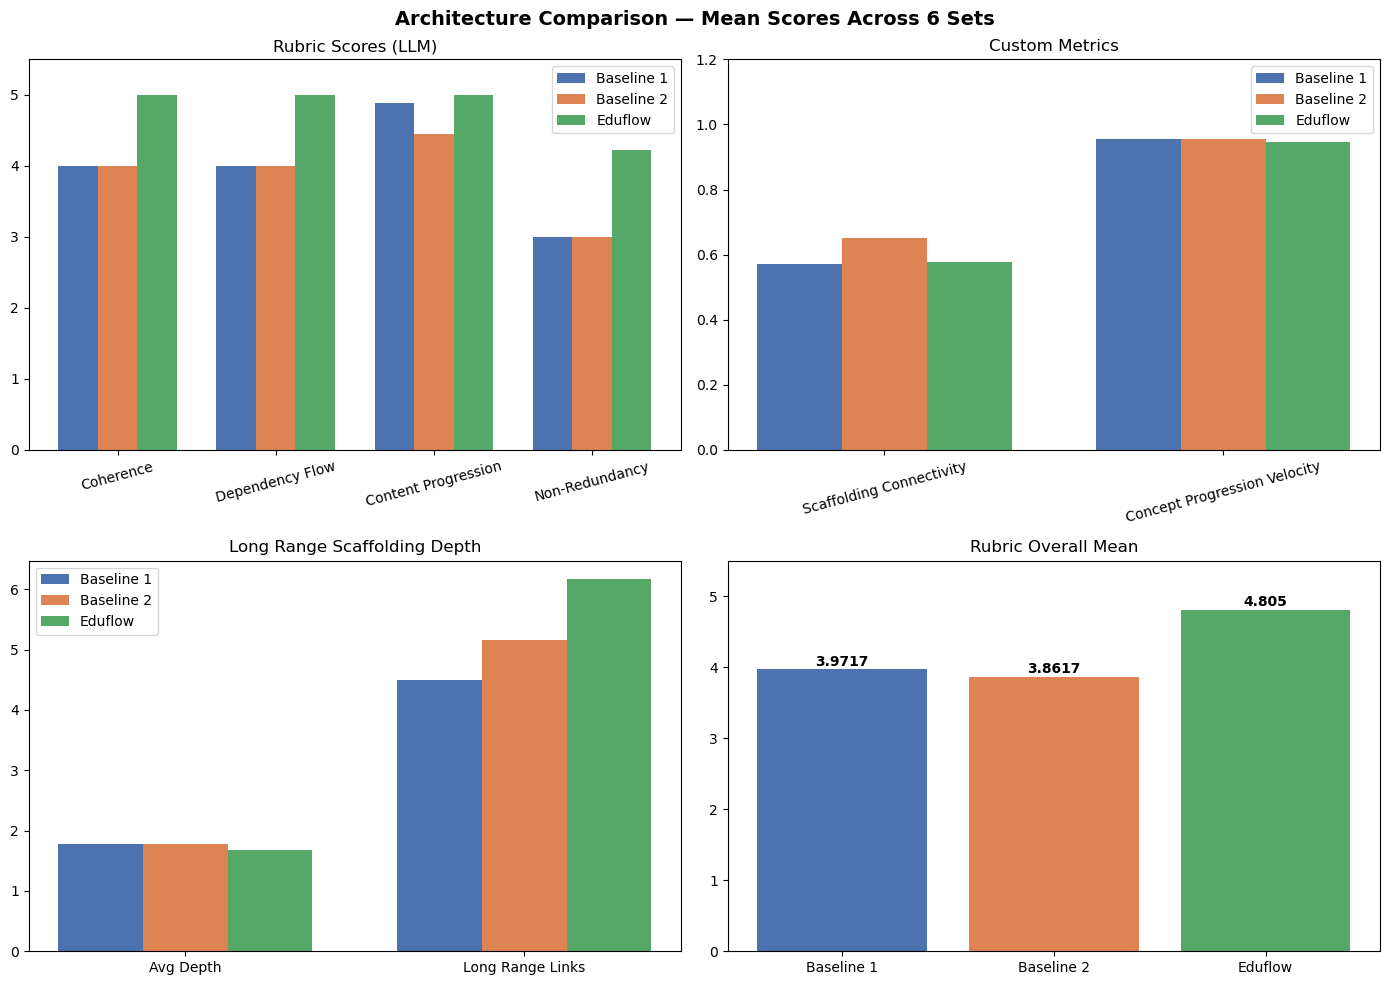

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Architecture Comparison — Mean Scores Across 6 Sets", fontsize=14, fontweight="bold")

architectures = summary.index.tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]  # blue, orange, green

# --- Plot 1: Rubric Scores ---
ax1 = axes[0, 0]
rubric_cols = ["rubric_coherence", "rubric_dependency_flow", "rubric_content_progression", "rubric_non_redundancy"]
rubric_labels = ["Coherence", "Dependency Flow", "Content Progression", "Non-Redundancy"]
x = np.arange(len(rubric_labels))
width = 0.25
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax1.bar(x + i * width, summary.loc[arch, rubric_cols], width, label=arch, color=color)
ax1.set_title("Rubric Scores (LLM)")
ax1.set_xticks(x + width)
ax1.set_xticklabels(rubric_labels, rotation=15)
ax1.set_ylim(0, 5.5)
ax1.legend()

# --- Plot 2: Custom Metrics ---
ax2 = axes[0, 1]
custom_cols = ["scs_overall", "cpv"]
custom_labels = ["Scaffolding Connectivity", "Concept Progression Velocity"]
x = np.arange(len(custom_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax2.bar(x + i * width, summary.loc[arch, custom_cols], width, label=arch, color=color)
ax2.set_title("Custom Metrics")
ax2.set_xticks(x + width)
ax2.set_xticklabels(custom_labels, rotation=15)
ax2.set_ylim(0, 1.2)
ax2.legend()

# --- Plot 3: Long Range Scaffolding ---
ax3 = axes[1, 0]
lrsd_cols = ["lrsd_avg_depth", "lrsd_long_range_links"]
lrsd_labels = ["Avg Depth", "Long Range Links"]
x = np.arange(len(lrsd_labels))
for i, (arch, color) in enumerate(zip(architectures, colors)):
    ax3.bar(x + i * width, summary.loc[arch, lrsd_cols], width, label=arch, color=color)
ax3.set_title("Long Range Scaffolding Depth")
ax3.set_xticks(x + width)
ax3.set_xticklabels(lrsd_labels)
ax3.legend()

# --- Plot 4: Rubric Overall Mean ---
ax4 = axes[1, 1]
ax4.bar(architectures, summary["rubric_overall_mean"], color=colors)
ax4.set_title("Rubric Overall Mean")
ax4.set_ylim(0, 5.5)
for i, v in enumerate(summary["rubric_overall_mean"]):
    ax4.text(i, v + 0.05, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

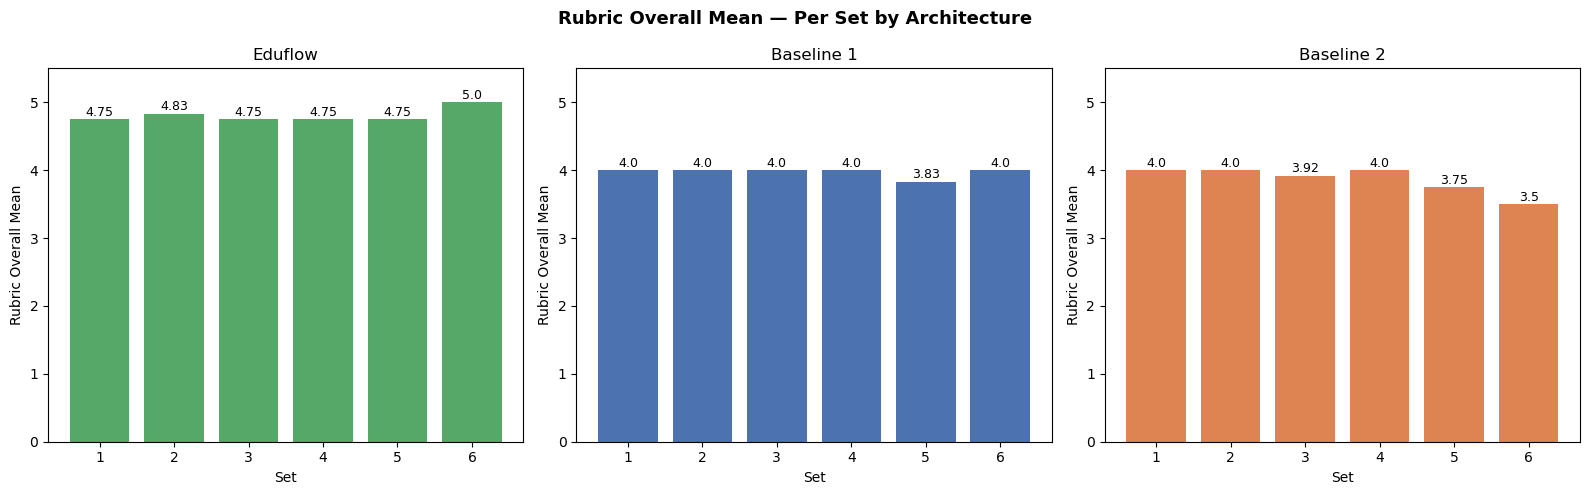

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Rubric Overall Mean — Per Set by Architecture", fontsize=13, fontweight="bold")

colors = {"Eduflow": "#55A868", "Baseline 1": "#4C72B0", "Baseline 2": "#DD8452"}
sets = [1, 2, 3, 4, 5, 6]

for ax, arch in zip(axes, ["Eduflow", "Baseline 1", "Baseline 2"]):
    subset = df[df["Architecture"] == arch].sort_values("Set")
    ax.bar(subset["Set"], subset["rubric_overall_mean"], color=colors[arch])
    ax.set_title(arch)
    ax.set_xlabel("Set")
    ax.set_ylabel("Rubric Overall Mean")
    ax.set_ylim(0, 5.5)
    ax.set_xticks(sets)
    for _, row in subset.iterrows():
        ax.text(row["Set"], row["rubric_overall_mean"] + 0.05, 
                str(round(row["rubric_overall_mean"], 2)), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
pairwise_df = df[df["pairwise_parsed"].notna()].copy()

print("Pairwise winner distribution:")
print(pairwise_df.groupby(["Architecture", "pairwise_winner"]).size())

print("\nPer set pairwise results:")
print(pairwise_df[["Set", "Architecture", "pairwise_winner", "pairwise_consensus"]])

Pairwise winner distribution:
Architecture  pairwise_winner
Baseline 1    sequence_a         6
Baseline 2    sequence_a         6
dtype: int64

Per set pairwise results:
    Set Architecture pairwise_winner                  pairwise_consensus
1     1   Baseline 1      sequence_a  sequence_a wins with 100% win rate
2     1   Baseline 2      sequence_a  sequence_a wins with 100% win rate
4     2   Baseline 1      sequence_a  sequence_a wins with 100% win rate
5     2   Baseline 2      sequence_a  sequence_a wins with 100% win rate
7     3   Baseline 1      sequence_a  sequence_a wins with 100% win rate
8     3   Baseline 2      sequence_a  sequence_a wins with 100% win rate
10    4   Baseline 1      sequence_a  sequence_a wins with 100% win rate
11    4   Baseline 2      sequence_a  sequence_a wins with 100% win rate
13    5   Baseline 1      sequence_a  sequence_a wins with 100% win rate
14    5   Baseline 2      sequence_a  sequence_a wins with 100% win rate
16    6   Baseline 1      s

In [15]:
print("Token Usage by Architecture:")
token_summary = df.groupby("Architecture")[["Total Input Tokens", "Total Output Tokens"]].agg(["mean", "sum"]).round(0)
print(token_summary)

print("\nCompletion Time by Architecture:")
print(df.groupby("Architecture")["Completion Time"].agg(["mean", "min", "max"]).round(2))

print("\nDuration by Architecture:")
print(df.groupby("Architecture")["Duration"].agg(["mean", "min", "max"]).round(2))

Token Usage by Architecture:
             Total Input Tokens         Total Output Tokens       
                           mean     sum                mean    sum
Architecture                                                      
Baseline 1              29660.0  177959              4755.0  28531
Baseline 2              38460.0  230760              7444.0  44662
Eduflow                 40609.0  243655             10126.0  60753

Completion Time by Architecture:
              mean  min  max
Architecture                
Baseline 1    26.0   26   26
Baseline 2    28.0   28   28
Eduflow       34.0   34   34

Duration by Architecture:
              mean  min  max
Architecture                
Baseline 1     5.0    5    5
Baseline 2     5.0    5    5
Eduflow        5.0    5    5
